In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

# Experiment 1

## load layouts and quantification files

In [4]:
Experiment1_Layout = pd.read_csv("/srv/scratch/z3532965/src/blana/Alex/260119_CytoplasmicPOLR2A_60x/260119_CytoplasmicPOLR2A.csv")

In [6]:
quantification_directory_1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260119_CytoplasmicPOLR2A/40x/20260128_175303_338/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

1539

In [7]:
Nuclei_quant_files = [i for i in quantification_files_1 if "nuclei_" in i]
Cyto_quant_files = [i for i in quantification_files_1 if "cyto_" in i]
Cell_quant_files = [i for i in quantification_files_1 if "cells_" in i]

In [8]:
# use WellC03 to define zeros for 561 and 647 channels, no IF
if_zeros = [x for x in Nuclei_quant_files if "C03" in x]

In [9]:
qdfs = list()


for f in tqdm(if_zeros):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_1['fov'] = fovs

100%|████████████████████████████████████████████| 9/9 [00:00<00:00, 184.32it/s]


In [10]:
IF_561_Zero, IF_640_Zero = quantifcation_pernuc_1['Nuclei_intensity_mean_561_2'].mean(), quantifcation_pernuc_1['Nuclei_intensity_mean_640_0'].mean()

In [11]:
qdfs = list()


for f in tqdm(Cell_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[10:13] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[48:52] for f in files]
quantifcation_percell_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 265.04it/s]


In [12]:
qdfs = list()


for f in tqdm(Nuclei_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 278.79it/s]


In [13]:
qdfs = list()


for f in tqdm(Cyto_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percyto_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percyto_1['file'].tolist()


wellnames = [f[9:12] for f in files]
quantifcation_percyto_1['well'] = wellnames

fovs = [f[47:51] for f in files]
quantifcation_percyto_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 260.18it/s]


In [14]:
# exclude border cells
quantifcation_percell_1 = quantifcation_percell_1.query('Cells_is_border == False')

In [15]:
Intensities = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CELL_IF_647_Intensity" : quantifcation_percell_1['Cells_intensity_mean_640_0'],
    "CELL_IF_561_Intensity" : quantifcation_percell_1['Cells_intensity_mean_561_2'],
    "CellArea" : quantifcation_percell_1['Cells_area']
})

In [16]:
IntensitiesPerNuclei = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NUCLEUS_IF_647_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_640_0'],
    "NUCLEUS_IF_561_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_561_2'],
    "Nucleus_DAPI_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_405_5'],
    "NucleusArea" : quantifcation_pernuc_1['Nuclei_area']
})

In [17]:
IntensitiesPerCyto = pd.DataFrame({
    "WELL" : quantifcation_percyto_1['well'],
    "FOV" : quantifcation_percyto_1['fov'],
    "LABEL" : quantifcation_percyto_1['label'],
    "CYTO_IF_647_Intensity" : quantifcation_percyto_1['Cytoplasm_intensity_mean_640_0'],
    "CYTO_IF_561_Intensity" : quantifcation_percyto_1['Cytoplasm_intensity_mean_561_2'],
    "CytoplasmArea" : quantifcation_percyto_1['Cytoplasm_area']
})

## subtract background

In [18]:
Intensities["CELL_IF_647_Intensity_BGS"] = Intensities["CELL_IF_647_Intensity"] - IF_640_Zero
Intensities["CELL_IF_561_Intensity_BGS"] = Intensities["CELL_IF_561_Intensity"] - IF_561_Zero

IntensitiesPerNuclei["NUCLEUS_IF_647_Intensity_BGS"] = IntensitiesPerNuclei["NUCLEUS_IF_647_Intensity"] - IF_640_Zero
IntensitiesPerNuclei["NUCLEUS_IF_561_Intensity_BGS"] = IntensitiesPerNuclei["NUCLEUS_IF_561_Intensity"] - IF_561_Zero

IntensitiesPerCyto["CYTO_IF_647_Intensity_BGS"] = IntensitiesPerCyto["CYTO_IF_647_Intensity"] - IF_640_Zero
IntensitiesPerCyto["CYTO_IF_561_Intensity_BGS"] = IntensitiesPerCyto["CYTO_IF_561_Intensity"] - IF_561_Zero

In [19]:
Intensities = Intensities.merge(IntensitiesPerNuclei, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Intensities = Intensities.merge(IntensitiesPerCyto, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])

In [20]:
## exclude cells with missing segmentation
Intensities.dropna(inplace = True)

In [21]:
## filter for cells with some segmented nuclei of minimum size contained within
Intensities = Intensities.query('NucleusArea > 500')

In [22]:
CountsByWell = Intensities.groupby('WELL').count()['NucleusArea'].reset_index().merge(Experiment1_Layout, how = 'left')
CountsByWell.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [23]:
IntensitiesByCell = Intensities.merge(Experiment1_Layout, how = 'left')

In [24]:
IntensitiesByWell = Intensities.drop(['FOV','LABEL'], axis = 1).groupby('WELL').mean().reset_index().merge(Experiment1_Layout, how = 'left')
IntensitiesByWell = IntensitiesByWell.merge(CountsByWell, how = 'left')

## normalise

In [25]:
IntensitiesByWell.CELL.unique(), IntensitiesByWell.PRIMARY_1.unique(), IntensitiesByWell.PRIMARY_2.unique()

(array(['HCT116', 'HCT116 mChPOLR2A clone 2'], dtype=object),
 array(['No primary', 'Total Pol II (F12)'], dtype=object),
 array(['No primary', 'mCherry'], dtype=object))

In [26]:
HCT116_IF_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()

IntensitiesByWell['NUCLEUS_F12_NORM'] = IntensitiesByWell['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_IF_NormValue
IntensitiesByWell['CYTO_F12_NORM'] = IntensitiesByWell['CYTO_IF_647_Intensity_BGS'] / HCT116_IF_NormValue

In [27]:
HCT116_mCh_647_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()
IntensitiesByWell['NUCLEUS_F12_NORM_MCHPOL'] = IntensitiesByWell['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_mCh_647_NormValue
IntensitiesByWell['CYTO_F12_NORM_MCHPOL'] = IntensitiesByWell['CYTO_IF_647_Intensity_BGS'] / HCT116_mCh_647_NormValue

In [28]:
HCT116_mCh_561_NormValue = IntensitiesByWell.query('DRUG == "No addition" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_2 == "mCherry"')['NUCLEUS_IF_561_Intensity_BGS'].mean()

IntensitiesByWell['NUCLEUS_MCH_NORM'] = IntensitiesByWell['NUCLEUS_IF_561_Intensity_BGS'] / HCT116_mCh_561_NormValue
IntensitiesByWell['CYTO_MCH_NORM'] = IntensitiesByWell['CYTO_IF_561_Intensity_BGS'] / HCT116_mCh_561_NormValue

# Experiment 2

In [29]:
Experiment2_Layout = pd.read_csv("/srv/scratch/z3532965/src/blana/Alex/260306_CytoplasmicPOLR2A/260306_CytoplasmicPOLR2A.csv")

In [30]:
quantification_directory_2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260306_CytoplasmicPOLR2A/20260310_190059_521/QUANTIFICATION/")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
len(quantification_files_2)

0

In [28]:
Nuclei_quant_files = [i for i in quantification_files_2 if "nuclei_" in i]
Cyto_quant_files = [i for i in quantification_files_2 if "cyto_" in i]
Cell_quant_files = [i for i in quantification_files_2 if "cells_" in i]

In [29]:
qdfs = list()


for f in tqdm(Cell_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[10:13] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[48:52] for f in files]
quantifcation_percell_2['fov'] = fovs

100%|██████████| 720/720 [00:16<00:00, 44.24it/s]


In [30]:
Path(Nuclei_quant_files[10]).stem, Path(Nuclei_quant_files[10]).stem[11:14],Path(Nuclei_quant_files[10]).stem[49:53]

('nuclei_WellH06_Channel647,488,561,XXX,XXX,405_Seq0034_0001.ome',
 'H06',
 '0034')

In [31]:
qdfs = list()


for f in tqdm(Nuclei_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_2['fov'] = fovs

100%|██████████| 720/720 [00:16<00:00, 44.83it/s]


In [32]:
Path(Cyto_quant_files[10]).stem, Path(Cyto_quant_files[10]).stem[9:12],Path(Cyto_quant_files[10]).stem[47:51]

('cyto_WellE16_Channel647,488,561,XXX,XXX,405_Seq0053_0003.ome', 'E16', '0053')

In [33]:
qdfs = list()


for f in tqdm(Cyto_quant_files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percyto_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percyto_2['file'].tolist()


wellnames = [f[9:12] for f in files]
quantifcation_percyto_2['well'] = wellnames

fovs = [f[47:51] for f in files]
quantifcation_percyto_2['fov'] = fovs

100%|██████████| 720/720 [00:16<00:00, 42.89it/s]


In [34]:
# exclude border cells
quantifcation_percell_2 = quantifcation_percell_2.query('Cells_is_border == False')

In [35]:
Intensities2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CELL_IF_647_Intensity" : quantifcation_percell_2['Cells_intensity_mean_647_0'],
    "CELL_IF_561_Intensity" : quantifcation_percell_2['Cells_intensity_mean_561_2'],
    "CellArea" : quantifcation_percell_2['Cells_area']
})

In [36]:
IntensitiesPerNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NUCLEUS_IF_647_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_647_0'],
    "NUCLEUS_IF_561_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_561_2'],
    "Nucleus_DAPI_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_405_5'],
    "NucleusArea" : quantifcation_pernuc_2['Nuclei_area']
})

In [37]:
IntensitiesPerCyto2 = pd.DataFrame({
    "WELL" : quantifcation_percyto_2['well'],
    "FOV" : quantifcation_percyto_2['fov'],
    "LABEL" : quantifcation_percyto_2['label'],
    "CYTO_IF_647_Intensity" : quantifcation_percyto_2['Cytoplasm_intensity_mean_647_0'],
    "CYTO_IF_561_Intensity" : quantifcation_percyto_2['Cytoplasm_intensity_mean_561_2'],
    "CytoplasmArea" : quantifcation_percyto_2['Cytoplasm_area']
})

In [38]:
Intensities2 = Intensities2.merge(IntensitiesPerNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Intensities2 = Intensities2.merge(IntensitiesPerCyto2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])

In [39]:
## exclude cells with missing segmentation
Intensities2.dropna(inplace = True)

In [40]:
## filter for cells with some nucleus segmented over a certain area
Intensities2 = Intensities2.query('NucleusArea > 500')

In [41]:
CountsByWell2 = Intensities2.groupby('WELL').count()['NucleusArea'].reset_index().merge(Experiment2_Layout, how = 'left')
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [42]:
IntensitiesByCell2 = Intensities2.merge(Experiment2_Layout, how = 'left')

In [43]:
IntensitiesByWell2 = Intensities2.drop(['FOV','LABEL'], axis = 1).groupby('WELL').mean().reset_index().merge(Experiment2_Layout, how = 'left')
IntensitiesByWell2 = IntensitiesByWell2.merge(CountsByWell, how = 'left')

## background subtract and normalise

In [44]:
IntensitiesByWell2.CELL.unique(), IntensitiesByWell2.PRIMARY_1.unique(), IntensitiesByWell2.PRIMARY_2.unique()

(array(['HCT116', 'HCT116 mChPOLR2A clone 2'], dtype=object),
 array(['Total Pol II (F12)', 'No primary'], dtype=object),
 array(['Total Pol II (D8L4Y)', 'mCherry', 'No primary'], dtype=object))

In [45]:
IF_647_Zero, IF_561_Zero = IntensitiesByWell2.query('PRIMARY_1 == "No primary"')['CELL_IF_647_Intensity'].mean(), IntensitiesByWell2.query('PRIMARY_2 == "No primary"')['CELL_IF_561_Intensity'].mean()

In [46]:
IntensitiesByWell2['CELL_IF_647_Intensity_BGS'] = IntensitiesByWell2['CELL_IF_647_Intensity'] - IF_647_Zero
IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] = IntensitiesByWell2['CYTO_IF_647_Intensity'] - IF_647_Zero
IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity'] - IF_647_Zero

IntensitiesByWell2['CELL_IF_561_Intensity_BGS'] = IntensitiesByWell2['CELL_IF_561_Intensity'] - IF_561_Zero 
IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] = IntensitiesByWell2['CYTO_IF_561_Intensity'] - IF_561_Zero 
IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity'] - IF_561_Zero 

In [47]:
HCT116_F12_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()

IntensitiesByWell2['NUCLEUS_F12_NORM'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_F12_NV
IntensitiesByWell2['CYTO_F12_NORM'] = IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] / HCT116_F12_NV

In [48]:
HCT116_D8L4Y_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116" & PRIMARY_2 == "Total Pol II (D8L4Y)"')['NUCLEUS_IF_561_Intensity_BGS'].mean()

IntensitiesByWell2['NUCLEUS_D8L4Y_NORM'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] / HCT116_D8L4Y_NV
IntensitiesByWell2['CYTO_D8L4Y_NORM'] = IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] / HCT116_D8L4Y_NV

In [49]:
IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')

,WELL,CELL_IF_647_Intensity,CELL_IF_561_Intensity,CellArea,NUCLEUS_IF_647_Intensity,NUCLEUS_IF_561_Intensity,Nucleus_DAPI_Intensity,NucleusArea,CYTO_IF_647_Intensity,CYTO_IF_561_Intensity,...,CELL_IF_647_Intensity_BGS,CYTO_IF_647_Intensity_BGS,NUCLEUS_IF_647_Intensity_BGS,CELL_IF_561_Intensity_BGS,CYTO_IF_561_Intensity_BGS,NUCLEUS_IF_561_Intensity_BGS,NUCLEUS_F12_NORM,CYTO_F12_NORM,NUCLEUS_D8L4Y_NORM,CYTO_D8L4Y_NORM
25,E15,330.723585,721.034163,9639.839498,399.415744,887.934199,729.420074,5726.189499,202.016559,401.762236,...,183.199370,54.492343,251.891528,589.216784,269.944857,756.116820,0.951362,0.205811,1.969478,0.703133
42,F16,312.867135,705.734986,11195.069926,395.929173,919.279179,645.939503,5997.664200,199.704209,407.334767,...,165.342919,52.179993,248.404957,573.917607,275.517388,787.461800,0.938194,0.197077,2.051123,0.717647
59,G17,291.349216,636.783521,10338.193240,355.435792,801.968183,646.521574,5952.779584,191.050901,371.415759,...,143.825001,43.526685,207.911576,504.966142,239.598380,670.150804,0.785255,0.164395,1.745560,0.624088


In [50]:
MCHPOL_F12_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()
IntensitiesByWell2['NUCLEUS_F12_NORM_MCHPOL'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] / MCHPOL_F12_NV
IntensitiesByWell2['CYTO_F12_NORM_MCHPOL'] = IntensitiesByWell2['CYTO_IF_647_Intensity_BGS'] / MCHPOL_F12_NV

In [51]:
MCHPOL_MCH_NV = IntensitiesByWell2.query('DRUG == "Vehicle" & CELL == "HCT116 mChPOLR2A clone 2" & PRIMARY_2 == "mCherry"')['NUCLEUS_IF_561_Intensity_BGS'].mean()

IntensitiesByWell2['NUCLEUS_MCH_NORM'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] / MCHPOL_MCH_NV
IntensitiesByWell2['CYTO_MCH_NORM'] = IntensitiesByWell2['CYTO_IF_561_Intensity_BGS'] / MCHPOL_MCH_NV

# concat dataframes and plot replicate wells between experiments

In [52]:
IntensitiesByWell['EXPERIMENT'] = "260119_CytoplasmicPOLR2A"
IntensitiesByWell2['EXPERIMENT'] = "260306_CytoplasmicPOLR2A"

In [53]:
Ints_By_Well = pd.concat([IntensitiesByWell, IntensitiesByWell2])

In [54]:
Ints_By_Well

,WELL,CELL_IF_647_Intensity,CELL_IF_561_Intensity,CellArea,CELL_IF_647_Intensity_BGS,CELL_IF_561_Intensity_BGS,NUCLEUS_IF_647_Intensity,NUCLEUS_IF_561_Intensity,Nucleus_DAPI_Intensity,NucleusArea,...,TotalNumberCells,NUCLEUS_F12_NORM,CYTO_F12_NORM,NUCLEUS_F12_NORM_MCHPOL,CYTO_F12_NORM_MCHPOL,NUCLEUS_MCH_NORM,CYTO_MCH_NORM,EXPERIMENT,NUCLEUS_D8L4Y_NORM,CYTO_D8L4Y_NORM
0,C03,160.067518,126.589921,8692.357887,-0.962363,-0.617225,159.987294,126.438883,535.100658,6177.791342,...,121505.0,-0.002601,-0.002571,-0.003140,-0.003104,-0.000680,-0.000150,260119_CytoplasmicPOLR2A,NaN,NaN
1,D03,160.697928,126.979662,8359.864152,-0.331952,-0.227484,160.644709,126.848258,575.867548,5736.588156,...,164640.0,-0.000961,-0.000876,-0.001160,-0.001058,-0.000318,0.000172,260119_CytoplasmicPOLR2A,NaN,NaN
2,D04,463.204034,155.437479,12103.359356,302.174154,28.230333,716.410494,168.882299,578.943715,5277.373074,...,71514.0,1.385424,0.174642,1.672682,0.210853,0.036872,0.012787,260119_CytoplasmicPOLR2A,NaN,NaN
3,D05,415.492593,153.094616,12473.549861,254.462713,25.887469,628.657177,165.127797,597.938314,5529.000255,...,86189.0,1.166519,0.146915,1.408389,0.177376,0.033550,0.012826,260119_CytoplasmicPOLR2A,NaN,NaN
4,D06,411.305894,150.322115,12778.289283,250.276014,23.114968,617.634968,160.849016,560.504503,5677.732603,...,103124.0,1.139024,0.139436,1.375192,0.168347,0.029764,0.010254,260119_CytoplasmicPOLR2A,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,H17,149.363156,694.303926,8954.339568,1.838940,562.486547,150.236221,857.094043,642.018266,5400.692024,...,NaN,0.010243,0.002450,0.011488,0.002748,0.982880,0.375945,260306_CytoplasmicPOLR2A,1.889147,0.722586
76,H18,265.022710,571.573999,12146.037162,117.498495,439.756620,330.759951,748.745031,599.939668,6285.473800,...,NaN,0.692058,0.134045,0.776195,0.150341,0.836048,0.289369,260306_CytoplasmicPOLR2A,1.606928,0.556182
77,H19,272.977919,585.431940,12540.134222,125.453703,453.614561,343.190111,767.296637,623.201787,6536.195365,...,NaN,0.739005,0.140466,0.828849,0.157544,0.861188,0.293483,260306_CytoplasmicPOLR2A,1.655250,0.564090
78,H20,268.931608,568.472985,11494.174624,121.407392,436.655607,324.215896,719.105332,599.918972,6653.345032,...,NaN,0.667342,0.114196,0.748474,0.128079,0.795880,0.252857,260306_CytoplasmicPOLR2A,1.529725,0.486005


In [55]:
Ints_By_Well.DRUG.unique(), Ints_By_Well.PRIMARY_1.unique(), Ints_By_Well.PRIMARY_2.unique()

(array(['No addition', 'Media only', 'Mg132 plus leptomycin B', 'Vehicle',
        'Mg132', 'CB6644', 'Leptomycin B', 'Mg132 plus CB6644'],
       dtype=object),
 array(['No primary', 'Total Pol II (F12)'], dtype=object),
 array(['No primary', 'mCherry', 'Total Pol II (D8L4Y)'], dtype=object))

In [56]:
drug_order_plot = ['Vehicle','Mg132','Leptomycin B','Mg132 plus leptomycin B']

In [57]:
pal = sns.color_palette([sns.color_palette('tab20')[15], sns.color_palette('tab20')[1],  sns.color_palette('tab20')[3], sns.color_palette('tab20')[9]])

In [58]:
Ints_By_Well.columns

Index(['WELL', 'CELL_IF_647_Intensity', 'CELL_IF_561_Intensity', 'CellArea',
       'CELL_IF_647_Intensity_BGS', 'CELL_IF_561_Intensity_BGS',
       'NUCLEUS_IF_647_Intensity', 'NUCLEUS_IF_561_Intensity',
       'Nucleus_DAPI_Intensity', 'NucleusArea', 'NUCLEUS_IF_647_Intensity_BGS',
       'NUCLEUS_IF_561_Intensity_BGS', 'CYTO_IF_647_Intensity',
       'CYTO_IF_561_Intensity', 'CytoplasmArea', 'CYTO_IF_647_Intensity_BGS',
       'CYTO_IF_561_Intensity_BGS', 'CELL', 'CELL_STAIN', 'DRUG',
       'DRUG_TIME_MINUTES', 'PRIMARY_1', 'SECONDARY_1', 'PRIMARY_2',
       'SECONDARY_2', 'TotalNumberCells', 'NUCLEUS_F12_NORM', 'CYTO_F12_NORM',
       'NUCLEUS_F12_NORM_MCHPOL', 'CYTO_F12_NORM_MCHPOL', 'NUCLEUS_MCH_NORM',
       'CYTO_MCH_NORM', 'EXPERIMENT', 'NUCLEUS_D8L4Y_NORM', 'CYTO_D8L4Y_NORM'],
      dtype='object')

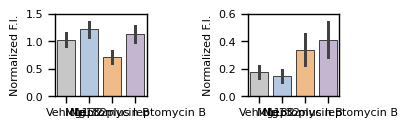

In [59]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

In [67]:
Ints_By_Well.EXPERIMENT.unique()

array(['260119_CytoplasmicPOLR2A', '260306_CytoplasmicPOLR2A'],
      dtype=object)

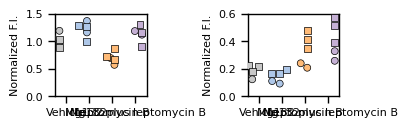

In [70]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260119_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                )

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260306_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                  marker = 's'
                )
g.legend().remove()

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260119_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                )

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot & EXPERIMENT == "260306_CytoplasmicPOLR2A"'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = 1, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                  marker = 's'
                )

g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

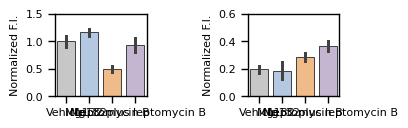

In [205]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM_MCHPOL',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM_MCHPOL',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/srv/scratch/z3536241/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/srv/scratch/z3536241/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/srv/scratch/z3536241/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


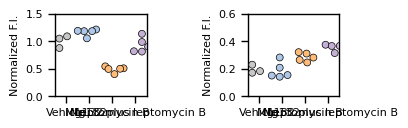

In [66]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_F12_NORM_MCHPOL',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = True, palette = pal,
                edgecolor = 'black', linewidth = 0.5
                )
g.legend().remove()

g = sns.swarmplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_F12_NORM_MCHPOL',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = True, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                )
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

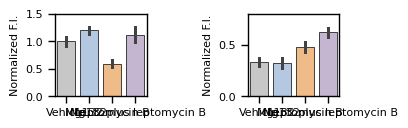

In [206]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'NUCLEUS_MCH_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot'),
              x = 'DRUG', order = drug_order_plot,
              y = 'CYTO_MCH_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.8)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.9)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

#plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

In [71]:
Ints_By_Well.DRUG.unique()

array(['No addition', 'Media only', 'Mg132 plus leptomycin B', 'Vehicle',
       'Mg132', 'CB6644', 'Leptomycin B', 'Mg132 plus CB6644'],
      dtype=object)

In [76]:
sns.color_palette('tab20')

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745)]

In [77]:
pal2 = sns.color_palette([sns.color_palette('tab20')[15], sns.color_palette('tab20')[1],  sns.color_palette('tab20')[3], sns.color_palette('tab20')[9], sns.color_palette('tab20')[11], sns.color_palette('tab20')[7]])

In [72]:
drug_order_plot_2 = ['Vehicle','Mg132','Leptomycin B','Mg132 plus leptomycin B', 'CB6644', 'Mg132 plus CB6644']

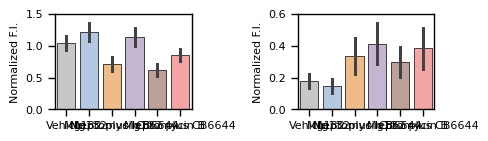

In [81]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

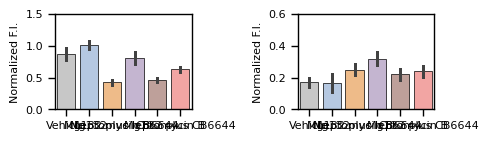

In [82]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'NUCLEUS_F12_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'CYTO_F12_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.6)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

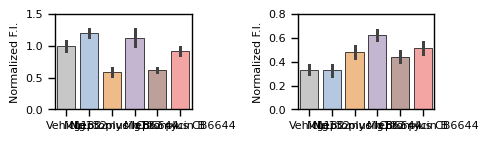

In [84]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (5,1.5))

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'NUCLEUS_MCH_NORM',
              ax = a[0],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

g = sns.barplot(Ints_By_Well.query('CELL == "HCT116 mChPOLR2A clone 2" & DRUG in @drug_order_plot_2'),
              x = 'DRUG', order = drug_order_plot_2,
              y = 'CYTO_MCH_NORM',
              ax = a[1],
              hue = 'DRUG', hue_order = drug_order_plot_2, dodge = False, palette = pal2,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()

a[0].set_ylim(0,1.5)
a[1].set_ylim(0,0.8)

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')